# 3 Noise2Void U-Net Denoiser

Self-supervised CNN denoiser trained on ARCADE coronary angiography images
without clean reference targets. A small U-Net learns to predict randomly
masked pixels from their neighbours — because the masked pixel's own noisy
value is hidden, the network is forced to learn the underlying signal rather
than copying noise.

Trained on the ARCADE train set (1000 images) with simulated Poisson noise.
Evaluated on the val set as part of the filter benchmark.

## 3.1 Unet Architecture

3-level encoder-decoder U-Net (`training/unet.py`) with skip connections
and bilinear upsampling. Single-channel input and output, float32 [0, 1].

Encoder: 16 → 32 → 64 → 128
Decoder mirrors encoder with skip connections

Key design choices:
- **Residual output**: predicts noise, not clean image.
  `clamp(x - out(d1), 0, 1)` — easier to learn, identity behaviour at init.
  Output conv layer is zero-initialised so training starts from pass-through.
- **GroupNorm** (num_groups=8) instead of BatchNorm — stable for small
  batches on CPU, independent of batch size.
- **bias=False** in conv layers — redundant alongside GroupNorm affine params.
- **base_channels=16** — ~125K parameters, feasible for CPU overnight training.

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import numpy as np
import torch

import importlib
import training.n2v_masking
import datasets.n2v_dataset
importlib.reload(training.n2v_masking)
importlib.reload(datasets.n2v_dataset)

from datasets.n2v_dataset import make_train_val_datasets

## 3.2 Dataset Design

**N2VDataset (train)** — `__getitem__` returns only the clean patch tensor `(1, 128, 128)`.
Dose reduction and masking of 2% pixels happen in the training loop, not here:
- - Dose is sampled per batch to ensure consistent noise statistics within each batch: `random.choices(DOSE_LEVELS, weights=DOSE_PROBS)`. This avoids gradient conflicts caused by mixed noise levels
- `reduce_dose()` applied to all patches in the batch together
- `mask_batch()` called once per batch
This ensures all patches in a batch see the same noise level — consistent
gradient direction per update step.

Sampling coordinates (vessel/background/fallback) are precomputed once per
image at init to avoid redundant `cv2.dilate` + `np.argwhere` calls during training.
Patches are biased 70% toward vessel regions (`VESSEL_BIAS=0.7`).

**N2VValDataset (val)** — returns fixed tuple `(masked, original, mask, patch_clean, f)`.
Dose and masking applied lazily in `__getitem__` with fixed per-item seed
`np.random.seed(idx)` — same patch, dose, and mask pattern every epoch.
Dose assigned deterministically: `f = DOSE_LEVELS[idx % len(DOSE_LEVELS)]`
for balanced coverage across all noise levels.

Dose levels: `[1.0, 0.5, 0.25, 0.1]`, training weights: `[0.2, 0.3, 0.3, 0.2]`.
Level 0.05 excluded from training to prevent over-smoothing; used only as
stress test in the benchmark.

In [2]:
train_ds, val_ds = make_train_val_datasets(root_dir="../data", patches_per_image=16)
print(f"Train size: {len(train_ds)} patches")
print(f"Val size:   {len(val_ds)} patches")

Train size: 14400 patches
Val size:   1600 patches


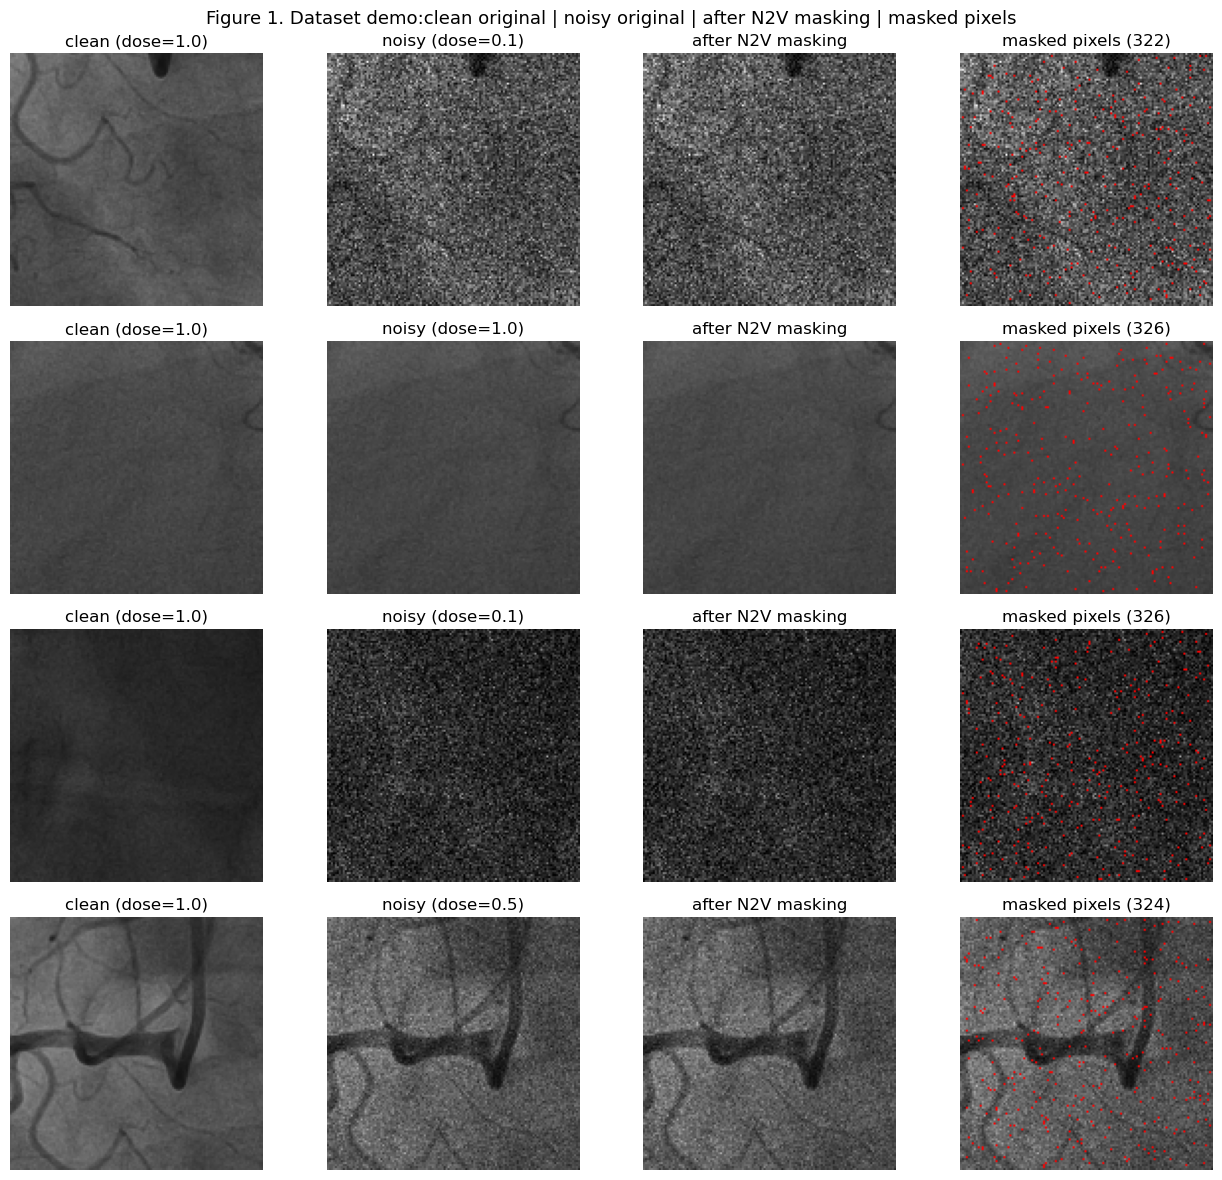

In [3]:
n = 4
items = [val_ds[i] for i in range(n)]
masked_patches   = torch.stack([m  for m, _, _, _, _ in items])
original_patches = torch.stack([o  for _, o, _, _, _ in items])
masks            = torch.stack([mk for _, _, mk, _, _ in items])
clean_patches    = torch.stack([c  for _, _, _, c, _  in items])
dose_levels      = [f for _, _, _, _, f in items]

fig, axes = plt.subplots(n, 4, figsize=(13, 3 * n))
fig.suptitle("Figure 1. Dataset demo:" \
"clean original | noisy original | after N2V masking | masked pixels", fontsize=13)

for i in range(n):
    clean = clean_patches[i, 0].numpy()
    orig  = original_patches[i, 0].numpy()
    mskd  = masked_patches[i, 0].numpy()
    msk   = masks[i, 0].numpy()

    overlay = np.stack([orig, orig, orig], axis=-1)
    overlay[msk == 1] = [1, 0, 0]

    axes[i, 0].imshow(clean, cmap="gray", vmin=0, vmax=1)
    axes[i, 0].set_title("clean (dose=1.0)")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(orig, cmap="gray", vmin=0, vmax=1)
    axes[i, 1].set_title(f"noisy (dose={dose_levels[i]})")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(mskd, cmap="gray", vmin=0, vmax=1)
    axes[i, 2].set_title("after N2V masking")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(overlay)
    axes[i, 3].set_title(f"masked pixels ({int(msk.sum())})")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

## 3.3.1 Training Loop

Each epoch (`training/train_n2v.py`):
1. Sample one dose per batch → apply `reduce_dose()` → apply `mask_batch()`
   → forward pass → masked MSE loss → backpropagate
2. Validate on fixed val patches, compute masked MSE loss
3. `ReduceLROnPlateau(patience=5, factor=0.5)` — halves LR on plateau
4. Early stopping after 10 epochs without improvement
5. Save `last.pt` every epoch, `best_val{loss}.pt` on improvement
   (previous best deleted to avoid accumulation)

**Logging** → `results/training_log.csv`, one row per epoch:
`epoch, train_loss, val_loss, lr, epoch_time_sec, train_loss_std,
loss_dose_1.0, loss_dose_0.5, loss_dose_0.25, loss_dose_0.1`

Per-dose loss reveals whether the network struggles at specific noise levels —
useful for diagnosing training issues after overnight runs.

In [4]:
from training.train_n2v import train
from pathlib import Path

_last_ckpt = Path("../training/checkpoints/last.pt")
resume = _last_ckpt.exists()
print(f"{'Resuming from last checkpoint' if resume else 'Starting fresh'}")
train(epochs=30, train_ds=train_ds, val_ds=val_ds, resume=resume)

Resuming from last checkpoint
Resumed from epoch 36, best val loss 0.008453


epochs: 0ep [00:00, ?ep/s]

## 3.3.1 Training Log

Loss curves from `results/training_log.csv`. Left: train (with ±1 std band) and val loss vs epoch. Right: per-dose train loss — reveals whether specific noise levels are harder to denoise.

C:\Users\Anna Lyamkina\AppData\Local\Temp\ipykernel_12360\1393675709.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


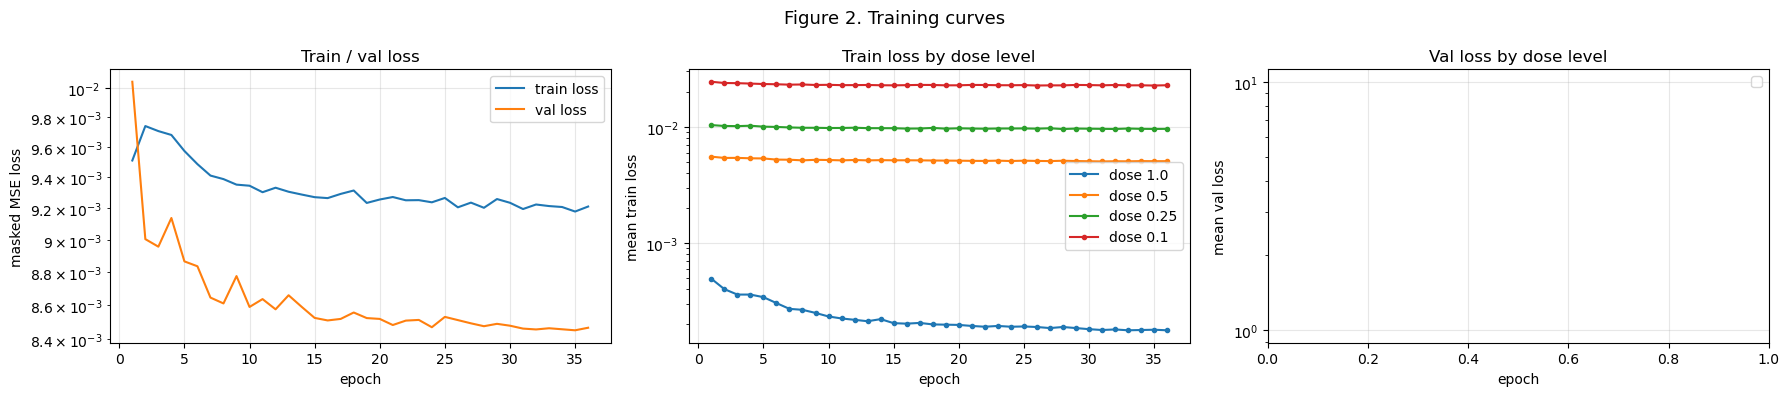

In [7]:
import pandas as pd
from pathlib import Path

log_path = Path("../results/training_log.csv")
assert log_path.exists(), "No training log found — run training first"

df = pd.read_csv(log_path)
df = df.apply(pd.to_numeric, errors="coerce")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Figure 2. Training curves", fontsize=13)

# --- train / val loss ---
ax1.plot(df["epoch"], df["train_loss"], label="train loss", color="tab:blue")
# ax1.fill_between(
#     df["epoch"],
#     df["train_loss"] - df["train_loss_std"],
#     df["train_loss"] + df["train_loss_std"],
#     alpha=0.2, color="tab:blue",
# )
ax1.plot(df["epoch"], df["val_loss"], label="val loss", color="tab:orange")
ax1.set_xlabel("epoch")
ax1.set_ylabel("masked MSE loss")
ax1.set_title("Train / val loss")
ax1.set_yscale("log")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- per-dose train loss ---
train_dose_cols = {
    "loss_dose_1.0": "dose 1.0", "loss_dose_0.5": "dose 0.5",
    "loss_dose_0.25": "dose 0.25", "loss_dose_0.1": "dose 0.1",
}
for col, label in train_dose_cols.items():
    if col in df.columns:
        ax2.plot(df["epoch"], df[col], label=label, marker="o", markersize=3)
ax2.set_xlabel("epoch")
ax2.set_ylabel("mean train loss")
ax2.set_title("Train loss by dose level")
ax2.set_yscale("log")
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- per-dose val loss ---
val_dose_cols = {
    "val_loss_dose_1.0": "dose 1.0", "val_loss_dose_0.5": "dose 0.5",
    "val_loss_dose_0.25": "dose 0.25", "val_loss_dose_0.1": "dose 0.1",
}
for col, label in val_dose_cols.items():
    if col in df.columns:
        ax3.plot(df["epoch"], df[col], label=label, marker="o", markersize=3)
ax3.set_xlabel("epoch")
ax3.set_ylabel("mean val loss")
ax3.set_title("Val loss by dose level")
ax3.set_yscale("log")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.4 Inference

Full image processed in a single forward pass — no masking, no tiling.
Network receives `(1, 1, 512, 512)` tensor, returns denoised image same shape.

`training/predict.py` — `apply_unet(image, checkpoint=CHECKPOINT_PATH)`:
- Model loaded lazily on first call, cached in `_model_cache` keyed by
  checkpoint path — no reloading between benchmark iterations
- Default checkpoint: `training/checkpoints/best*.pt`
- Alternative checkpoints passed explicitly, e.g. `last.pt`
- Device auto-detected: CUDA if available, otherwise CPU

Matches the interface of all classical filters — `image → image`,
float32 [0,1] — slots directly into the benchmark loop in notebook 03.

Loading best_val0i008453.pt


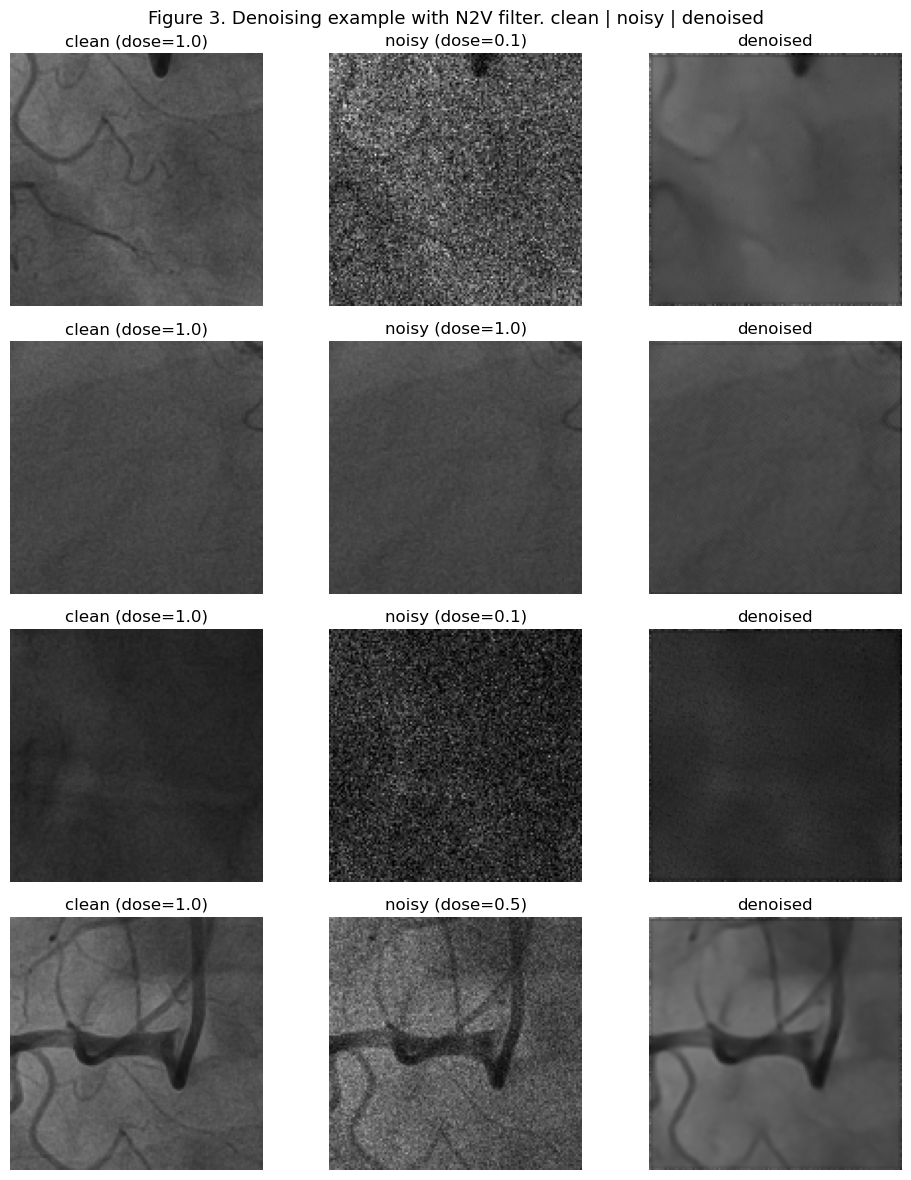

In [6]:
from training.predict import apply_unet
from pathlib import Path

checkpoints = sorted(Path("../training/checkpoints").glob("best_*.pt"))
assert checkpoints, "No best checkpoint found — run training first"
checkpoint = checkpoints[-1]
print(f"Loading {checkpoint.name}")

n = 4
items = [val_ds[i] for i in range(n)]
clean_patches    = [c[0].numpy() for _, _, _, c, _ in items]
noisy_patches    = [o[0].numpy() for _, o, _, _, _ in items]
dose_levels      = [f for _, _, _, _, f in items]
denoised_patches = [apply_unet(p, checkpoint) for p in noisy_patches]

fig, axes = plt.subplots(n, 3, figsize=(10, 3 * n))
fig.suptitle("Figure 3. Denoising example with N2V filter. " \
"clean | noisy | denoised", fontsize=13)

for i in range(n):
    axes[i, 0].imshow(clean_patches[i], cmap="gray", vmin=0, vmax=1)
    axes[i, 0].set_title("clean (dose=1.0)")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(noisy_patches[i], cmap="gray", vmin=0, vmax=1)
    axes[i, 1].set_title(f"noisy (dose={dose_levels[i]})")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(denoised_patches[i], cmap="gray", vmin=0, vmax=1)
    axes[i, 2].set_title("denoised")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()